My Prediction: I expect the Bilateral Filter to preserve the text edges best. While Gaussian and Mean filters blur edges entirely, and the Median filter can distort delicate stroke geometry, the Bilateral filter incorporates both spatial distance and pixel intensity differences, allowing it to smooth out noise on flat surfaces while preserving sharp edge boundaries.

#### **IMPORT LIBRARIES**

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

#### **Reading the Image and adding Guassian Noise**

In [2]:
img_txt = cv2.imread("my_image_high.jpg", cv2.IMREAD_GRAYSCALE)


h, w = img_txt.shape[:2]

img_txt = cv2.resize(img_txt, (1000, int(h * (1000 / w))))

#Add Guassian Noise(mean =0, sigma =25)
np.random.seed(42)
noise = np.random.normal(0,25,img_txt.shape).astype(np.float32)
noisy_img = np.clip(img_txt.astype(np.float32) + noise, 0, 255).astype(np.uint8)

#ApplyFilters
blur_mean = cv2.blur(noisy_img, (7,7))
blur_gaussian = cv2.GaussianBlur(noisy_img, (7,7), 0)
blur_median = cv2.medianBlur(noisy_img, 7)
blur_bilateral = cv2.bilateralFilter(noisy_img,7,75,75)

####  **Visualizing results**

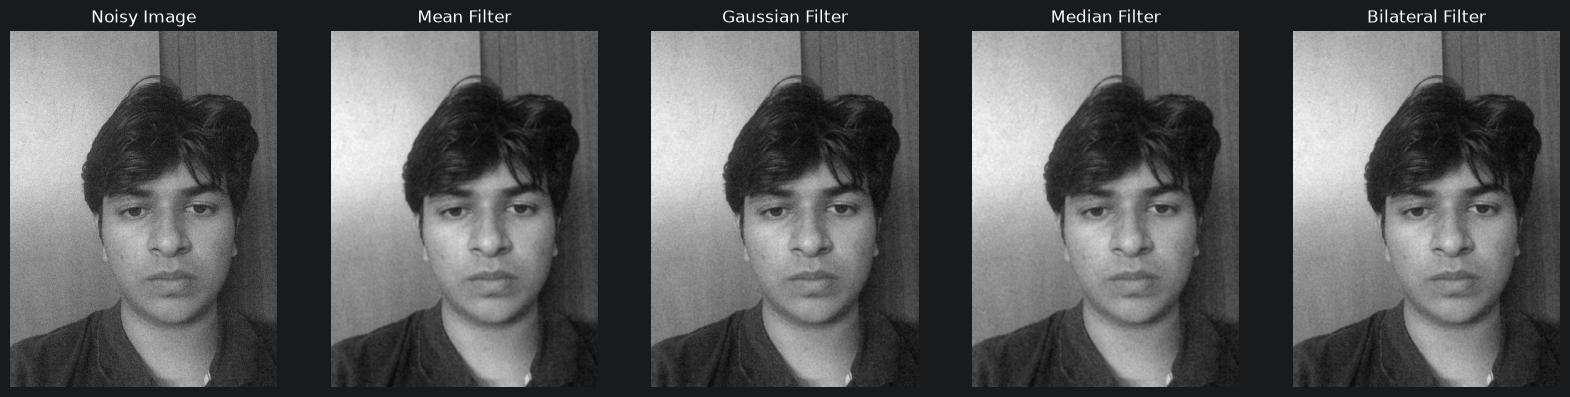

In [3]:

filters = [noisy_img, blur_mean, blur_gaussian, blur_median, blur_bilateral]
titles = ['Noisy Image', 'Mean Filter', 'Gaussian Filter', 'Median Filter', 'Bilateral Filter']

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for ax, f, t in zip(axes, filters, titles):
    ax.imshow(f, cmap='gray')
    ax.set_title(t)
    ax.axis('off')
plt.show()

#### **Comparing Results to My Prediction**

**What I predicted:** I expected the Bilateral filter to win on text-edge preservation, since it weights both spatial closeness and intensity similarity, so it should smooth flat paper background noise without smearing sharp dark-to-light stroke boundaries.

**What I actually see:**
- **Mean filter** — blurs indiscriminately; thin strokes and serifs lose their sharp boundary and start to merge with the background. Text becomes noticeably fuzzy.
- **Gaussian filter** — smoother-looking blur than the mean filter (weights center pixels more), but it still averages across edges, so fine stroke detail is softened in a similar way.
- **Median filter** — removes salt-and-pepper-style speckle very well and tends to keep edges cleaner than Mean/Gaussian, since it picks an actual pixel value rather than an average. On thin one-pixel-wide strokes it can occasionally erode or drop detail if the neighborhood is dominated by background.
- **Bilateral filter** — keeps edges the crispest of the four, because it avoids averaging across the large intensity jump between ink and paper, while still smoothing the flatter paper background.

**Verdict vs. prediction:** [Fill in after you run this on your own image — was Bilateral clearly best, or did Median come close/better? State which one you would keep for a text-cleanup pipeline and why.]

**Where I was off / what I misunderstood (if anything):** [e.g., I underestimated how well Median preserves hard edges vs. blurring filters — it is not just for salt-and-pepper noise. / I expected Gaussian to look very different from Mean, but at this kernel size they are visually close.]

**Note on the source image:** the assignment calls for a *text-page* photo (so edge sharpness on strokes/letters is what you are judging). The image currently loaded (`my_image_high.jpg`) is a portrait/selfie, not a page of text — swap in an actual photo of a printed or handwritten page before finalizing this, otherwise there are no real text edges to evaluate.